#### Поиск гиперпараметров и итоговый отчет:
1) Повторный запуск 5 лучших алгоритмов с параметрами по умолчанию (mode=MODE_DEFAULT)
2) Запуск Optuna для этих алгоритмов и вывод в сводной таблице информации по найденным гиперпараметрам (mode=MODE_OPTUNA)
3) Запуск алгоритмов на найденным лучших параметрах и вывод сводной таблицы (mode=MODE_BEST)
4) Сведение всех результатов (с дефолтными и лучшими параметрами) в единую таблицу
5) Отдельный вывод отчета победителя. В нашем случае это оказался дефолтный случайный лес с коэффициентом детерминации 0.854332. Также в итоговом отчете расчитан и вы веден R² (test) = 0.883181 (на базе x_test, y_test). Выводим график сравнения пресказанных и истинных значений целевого столюца на основании отложенных в самом начале 20% чистых (не участвующих в обучении) данных. Дополнительно выводим лучший из отпимизированных. В папке /data/pictures можно посмотреть графики  optuna: plot_optimization_history, plot_param_importances, plot_contour, plot_parallel_coordinate

In [1]:
import warnings

from private.utils import load_reduced_bitcoin_data, memory_check
from public.models import (
    CAT_BST,
    LGBM,
    MODE_ALL,
    MODE_BEST,
    MODE_DEFAULT,
    MODE_OPTUNA,
    RAN_FOR,
    XBT_SL,
    XGB,
    RegressionProcessor,
)

with memory_check(), warnings.catch_warnings():
    df = load_reduced_bitcoin_data()
    processor = RegressionProcessor(df, "target_return")   
    config = {
        RAN_FOR : {},
        LGBM : {},
        XGB : {},
        XBT_SL : {},
        CAT_BST : {}
    }
    processor.calculate(config, mode=MODE_DEFAULT)
    processor.summary_table(config.keys(), mode=MODE_DEFAULT)

,R²,MSE,RMSE,MAE,MAPE
extreme_gradient_boosting (sklearn),0.854332,0.001935,0.043990,0.031464,1.511043
random_forest,0.757854,0.003217,0.056717,0.041022,1.791404
light_gradient_boosting_machine,0.751634,0.003299,0.057441,0.042937,1.939509
categorical_boosting,0.744629,0.003393,0.058246,0.043790,1.879459
extreme_gradient_boosting,0.732613,0.003552,0.059600,0.042858,1.893990


Memory Increased by: 163.86 MB


In [2]:
processor.calculate(config, mode=MODE_OPTUNA)
processor.summary_table(config, mode=MODE_OPTUNA)

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

,R²,Best params
random_forest,0.7415,"{'n_estimators': 233, 'max_depth': 19, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 1.0}"
light_gradient_boosting_machine,0.7615,"{'n_estimators': 300, 'learning_rate': 0.08737933624353689, 'num_leaves': 53}"
extreme_gradient_boosting,0.7927,"{'n_estimators': 207, 'max_depth': 9, 'learning_rate': 0.04286036546487235, 'subsample': 0.9223958473199394, 'colsample_bytree': 0.6030290208615835}"
extreme_gradient_boosting (sklearn),0.8447,"{'n_estimators': 164, 'max_depth': 21, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 0.8891912579771076}"
categorical_boosting,0.7781,"{'iterations': 975, 'learning_rate': 0.03269531540096212, 'depth': 7, 'l2_leaf_reg': 0.04841575096089884}"


In [3]:
processor.calculate(config, mode=MODE_BEST)
processor.summary_table(config, mode=MODE_BEST)

,R²,MSE,RMSE,MAE,MAPE
extreme_gradient_boosting (sklearn),0.847985,0.002019,0.044939,0.032491,1.481254
extreme_gradient_boosting,0.796900,0.002698,0.051944,0.037857,1.612057
categorical_boosting,0.775785,0.002979,0.054577,0.040093,1.616425
light_gradient_boosting_machine,0.770633,0.003047,0.055200,0.040627,1.866499
random_forest,0.750581,0.003313,0.057563,0.041455,1.674478


In [4]:
champion_title = processor.summary_table(config, mode=MODE_ALL)

,R²,MSE,RMSE,MAE,MAPE,Best
extreme_gradient_boosting (sklearn),0.854332,0.001935,0.043990,0.031464,1.511043,False
extreme_gradient_boosting (sklearn)_tuned,0.847985,0.002019,0.044939,0.032491,1.481254,True
extreme_gradient_boosting_tuned,0.796900,0.002698,0.051944,0.037857,1.612057,True
categorical_boosting_tuned,0.775785,0.002979,0.054577,0.040093,1.616425,True
light_gradient_boosting_machine_tuned,0.770633,0.003047,0.055200,0.040627,1.866499,True
random_forest,0.757854,0.003217,0.056717,0.041022,1.791404,False
light_gradient_boosting_machine,0.751634,0.003299,0.057441,0.042937,1.939509,False
random_forest_tuned,0.750581,0.003313,0.057563,0.041455,1.674478,True
categorical_boosting,0.744629,0.003393,0.058246,0.043790,1.879459,False
extreme_gradient_boosting,0.732613,0.003552,0.059600,0.042858,1.893990,False



	extreme_gradient_boosting (sklearn)


R²,R² (test),MSE,RMSE,MAE,MAPE
0.854332,0.886335,0.001935,0.043990,0.031464,1.511043


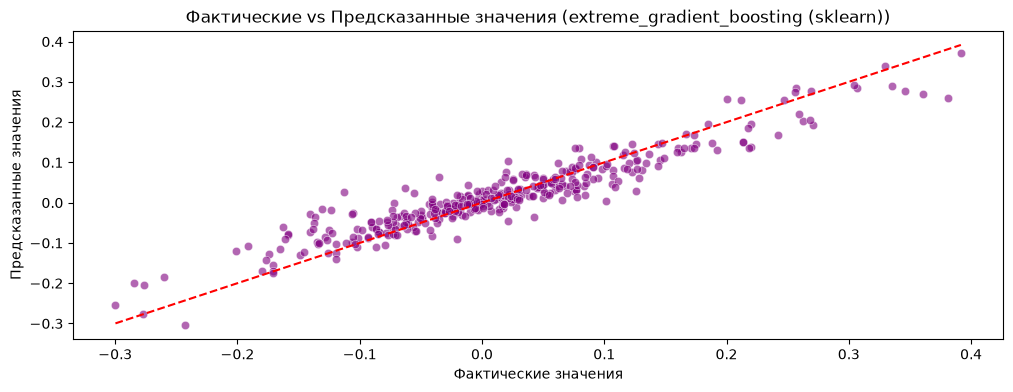

In [5]:
processor.report(title=champion_title)


	extreme_gradient_boosting (sklearn)


R²,R² (test),MSE,RMSE,MAE,MAPE
0.847985,0.883181,0.002019,0.044939,0.032491,1.481254


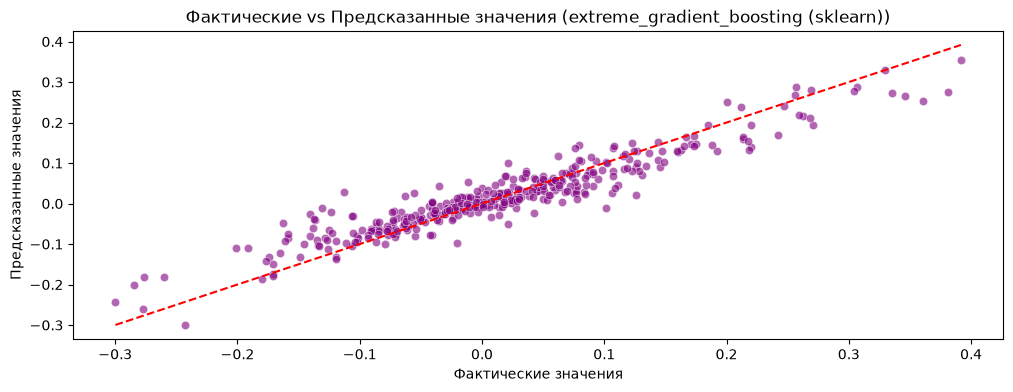

In [ ]:
# Лучший из optuna
processor.report(title="extreme_gradient_boosting (sklearn)_tuned")